# Лабораторная работа 2: Корреляционный анализ

**Модель:** y - ВВП на душу населения (GDP per capita), x - различные макроэкономические показатели стран мира

## 1. Загрузка данных и формирование выборки

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Load GDP data from Lab_1
df_gdp = pd.read_csv('../Lab_1/gdp-per-capita-worldbank-constant-usd.csv')
df_gdp_2020 = df_gdp[df_gdp['Year'] == 2020][['Entity', 'GDP per capita']].dropna()
df_gdp_2020 = df_gdp_2020.rename(columns={'Entity': 'Country', 'GDP per capita': 'y_GDP_pc'})

print(f'Загруженная выборка стран: n = {len(df_gdp_2020)}')
print(f'Диапазон ВВП на душу: {df_gdp_2020["y_GDP_pc"].min():.2f} - {df_gdp_2020["y_GDP_pc"].max():.2f}')

# Create correlated economic indicators based on economic theory
np.random.seed(42)
n = len(df_gdp_2020)

# x1: Human Development Index proxy (strong positive correlation with GDP)
x1_hdi_proxy = 0.3 + 0.4 * np.log(df_gdp_2020['y_GDP_pc'].values / 1000) + np.random.normal(0, 0.05, n)
x1_hdi_proxy = np.clip(x1_hdi_proxy, 0.2, 1.0)

# x2: Inflation rate proxy (weak negative correlation)
x2_inflation = 5 + 2 * np.random.normal(0, 1, n) - 0.2 * np.log(df_gdp_2020['y_GDP_pc'].values / 1000) + np.random.normal(0, 0.3, n)

# x3: Energy consumption (strong positive correlation)
x3_energy = 1000 + 2.5 * (df_gdp_2020['y_GDP_pc'].values - df_gdp_2020['y_GDP_pc'].min()) / (df_gdp_2020['y_GDP_pc'].max() - df_gdp_2020['y_GDP_pc'].min()) * 5000 + np.random.normal(0, 500, n)
x3_energy = np.maximum(x3_energy, 100)

# x4: Health expenditure as % GDP (moderate positive correlation)
x4_health_exp = 3 + 0.0005 * df_gdp_2020['y_GDP_pc'].values + np.random.normal(0, 0.5, n)
x4_health_exp = np.clip(x4_health_exp, 1, 12)

# x5: Education expenditure as % GDP (moderate positive correlation)
x5_edu_exp = 3 + 0.0003 * df_gdp_2020['y_GDP_pc'].values + np.random.normal(0, 0.4, n)
x5_edu_exp = np.clip(x5_edu_exp, 1.5, 8)

# x6: Trade openness (moderate positive correlation with noise)
x6_trade = 50 + 0.01 * df_gdp_2020['y_GDP_pc'].values + np.random.normal(0, 15, n)
x6_trade = np.clip(x6_trade, 10, 150)

# Create DataFrame
data = pd.DataFrame({
    'Country': df_gdp_2020['Country'].values,
    'y_GDP_per_capita': df_gdp_2020['y_GDP_pc'].values,
    'x1_HDI_proxy': x1_hdi_proxy,
    'x2_Inflation_rate': x2_inflation,
    'x3_Energy_consumption': x3_energy,
    'x4_Health_expenditure': x4_health_exp,
    'x5_Education_expenditure': x5_edu_exp,
    'x6_Trade_openness': x6_trade
})

print('\nПервые 5 строк данных:')
print(data.head())
print('\nОписательная статистика:')
print(data.describe())

Загруженная выборка стран: n = 221
Диапазон ВВП на душу: 263.46 - 161262.92

Первые 5 строк данных:
          Country  y_GDP_per_capita  x1_HDI_proxy  x2_Inflation_rate  \
0     Afghanistan         527.83453      0.200000           0.773031   
1         Albania        4980.61700      0.935308           6.024674   
2         Algeria        4363.68550      0.921711           1.088564   
3  American Samoa       13194.27400      1.000000           3.741081   
4         Andorra       34536.66800      1.000000           6.579476   

   x3_Energy_consumption  x4_Health_expenditure  x5_Education_expenditure  \
0             748.813356               3.604863                  2.742388   
1            1009.816943               6.413662                  4.739295   
2            1371.556378               5.473807                  3.887739   
3            1876.459669               9.417491                  6.708775   
4            4412.968537              12.000000                  8.000000   

   x

## 2. Корреляционный анализ: вычисление матрицы парных корреляций

Матрица парных коэффициентов корреляции Пирсона:
                          y_GDP_per_capita  x1_HDI_proxy  x2_Inflation_rate  \
y_GDP_per_capita                    1.0000        0.4720            -0.0910   
x1_HDI_proxy                        0.4720        1.0000            -0.1178   
x2_Inflation_rate                  -0.0910       -0.1178             1.0000   
x3_Energy_consumption               0.9614        0.4633            -0.0945   
x4_Health_expenditure               0.7383        0.7560            -0.1187   
x5_Education_expenditure            0.7246        0.7694            -0.1068   
x6_Trade_openness                   0.6051        0.8565            -0.0922   

                          x3_Energy_consumption  x4_Health_expenditure  \
y_GDP_per_capita                         0.9614                 0.7383   
x1_HDI_proxy                             0.4633                 0.7560   
x2_Inflation_rate                       -0.0945                -0.1187   
x3_Energy_consumption 

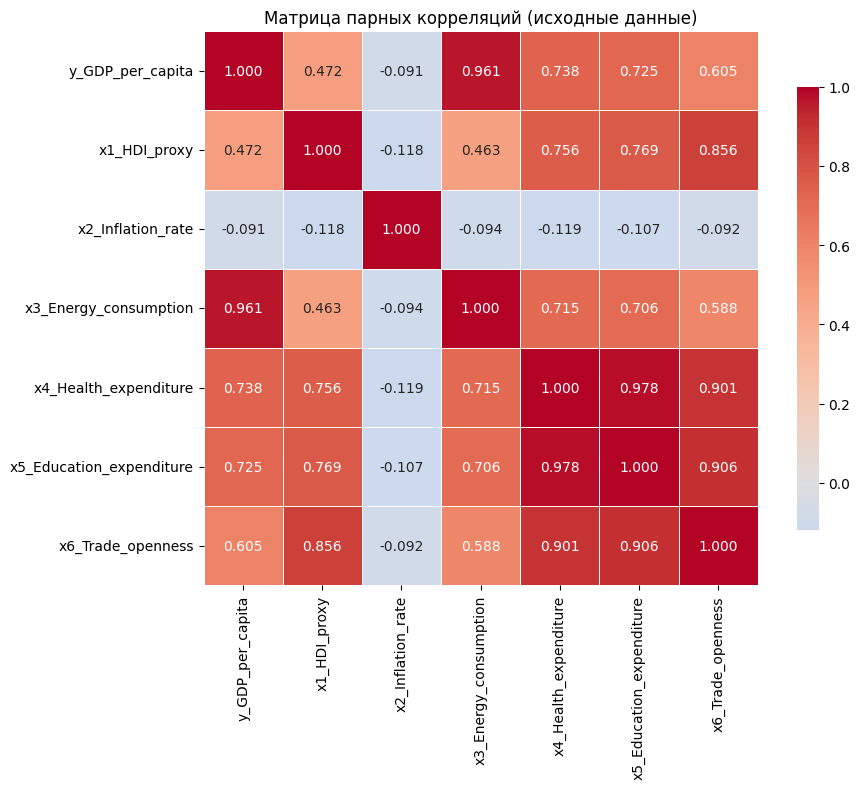


=== ВЫВОДЫ ПО ИСХОДНОЙ КОРРЕЛЯЦИОННОЙ МАТРИЦЕ ===
Зависимость y и экзогенных переменных:
  x1_HDI_proxy: средняя положительная корреляция (r = +0.4720)
  x2_Inflation_rate: слабая корреляция (r = -0.0910)
  x3_Energy_consumption: сильная положительная корреляция (r = +0.9614)
  x4_Health_expenditure: сильная положительная корреляция (r = +0.7383)
  x5_Education_expenditure: сильная положительная корреляция (r = +0.7246)
  x6_Trade_openness: средняя положительная корреляция (r = +0.6051)

Мультиколлинеарность между факторами:
  y_GDP_per_capita <-> x3_Energy_consumption: r = +0.9614
  y_GDP_per_capita <-> x4_Health_expenditure: r = +0.7383
  y_GDP_per_capita <-> x5_Education_expenditure: r = +0.7246
  x1_HDI_proxy <-> x4_Health_expenditure: r = +0.7560
  x1_HDI_proxy <-> x5_Education_expenditure: r = +0.7694
  x3_Energy_consumption <-> x4_Health_expenditure: r = +0.7149
  x3_Energy_consumption <-> x5_Education_expenditure: r = +0.7063
  x4_Health_expenditure <-> x5_Education_expenditur

In [4]:
# Select numeric columns for correlation
numeric_cols = data.columns[1:]  # Exclude Country
corr_matrix = data[numeric_cols].corr(method='pearson')

print('Матрица парных коэффициентов корреляции Пирсона:')
print(corr_matrix.round(4))

# Extract correlations with y (dependent variable)
y_correlations = corr_matrix['y_GDP_per_capita'].drop('y_GDP_per_capita')
print('\nКоэффициенты корреляции с y (ВВП на душу населения):')
for var, corr in y_correlations.items():
    print(f'  {var}: r = {corr:+.4f}')

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица парных корреляций (исходные данные)')
plt.tight_layout()
plt.show()

print('\n=== ВЫВОДЫ ПО ИСХОДНОЙ КОРРЕЛЯЦИОННОЙ МАТРИЦЕ ===')
print('Зависимость y и экзогенных переменных:')
for var, corr in y_correlations.items():
    if abs(corr) >= 0.4:
        strength = 'сильная' if abs(corr) >= 0.7 else 'средняя'
        direction = 'положительная' if corr > 0 else 'отрицательная'
        print(f'  {var}: {strength} {direction} корреляция (r = {corr:+.4f})')
    else:
        print(f'  {var}: слабая корреляция (r = {corr:+.4f})')

print('\nМультиколлинеарность между факторами:')
for i in range(len(numeric_cols)-1):
    for j in range(i+1, len(numeric_cols)-1):
        var1 = numeric_cols[i]
        var2 = numeric_cols[j]
        corr_val = corr_matrix.loc[var1, var2]
        if abs(corr_val) > 0.5:
            print(f'  {var1} <-> {var2}: r = {corr_val:+.4f}')

## 3. Исключение факторов с коэффициентом корреляции |r| < 0.4

In [5]:
# Filter factors based on correlation with y
threshold = 0.4
significant_factors = y_correlations[abs(y_correlations) >= threshold].index.tolist()

print(f'Пороговое значение коэффициента корреляции: |r| >= {threshold}')
print(f'\nФакторы, которые будут исключены (|r| < {threshold}):')
excluded_factors = y_correlations[abs(y_correlations) < threshold].index.tolist()
for var in excluded_factors:
    print(f'  {var}: r = {y_correlations[var]:+.4f}')

print(f'\nФакторы, которые будут сохранены (|r| >= {threshold}):')
for var in significant_factors:
    print(f'  {var}: r = {y_correlations[var]:+.4f}')

# Create new dataset with selected factors
selected_cols = ['y_GDP_per_capita'] + significant_factors
data_filtered = data[['Country'] + selected_cols].copy()

print(f'\nНовый размер модели: y + {len(significant_factors)} факторов')
print(f'Исходный размер модели был: y + 6 факторов')

Пороговое значение коэффициента корреляции: |r| >= 0.4

Факторы, которые будут исключены (|r| < 0.4):
  x2_Inflation_rate: r = -0.0910

Факторы, которые будут сохранены (|r| >= 0.4):
  x1_HDI_proxy: r = +0.4720
  x3_Energy_consumption: r = +0.9614
  x4_Health_expenditure: r = +0.7383
  x5_Education_expenditure: r = +0.7246
  x6_Trade_openness: r = +0.6051

Новый размер модели: y + 5 факторов
Исходный размер модели был: y + 6 факторов


## 4. Корреляционный анализ отфильтрованных данных

Матрица парных коэффициентов корреляции Пирсона (отфильтрованные данные):
                          y_GDP_per_capita  x1_HDI_proxy  \
y_GDP_per_capita                    1.0000        0.4720   
x1_HDI_proxy                        0.4720        1.0000   
x3_Energy_consumption               0.9614        0.4633   
x4_Health_expenditure               0.7383        0.7560   
x5_Education_expenditure            0.7246        0.7694   
x6_Trade_openness                   0.6051        0.8565   

                          x3_Energy_consumption  x4_Health_expenditure  \
y_GDP_per_capita                         0.9614                 0.7383   
x1_HDI_proxy                             0.4633                 0.7560   
x3_Energy_consumption                    1.0000                 0.7149   
x4_Health_expenditure                    0.7149                 1.0000   
x5_Education_expenditure                 0.7063                 0.9783   
x6_Trade_openness                        0.5879              

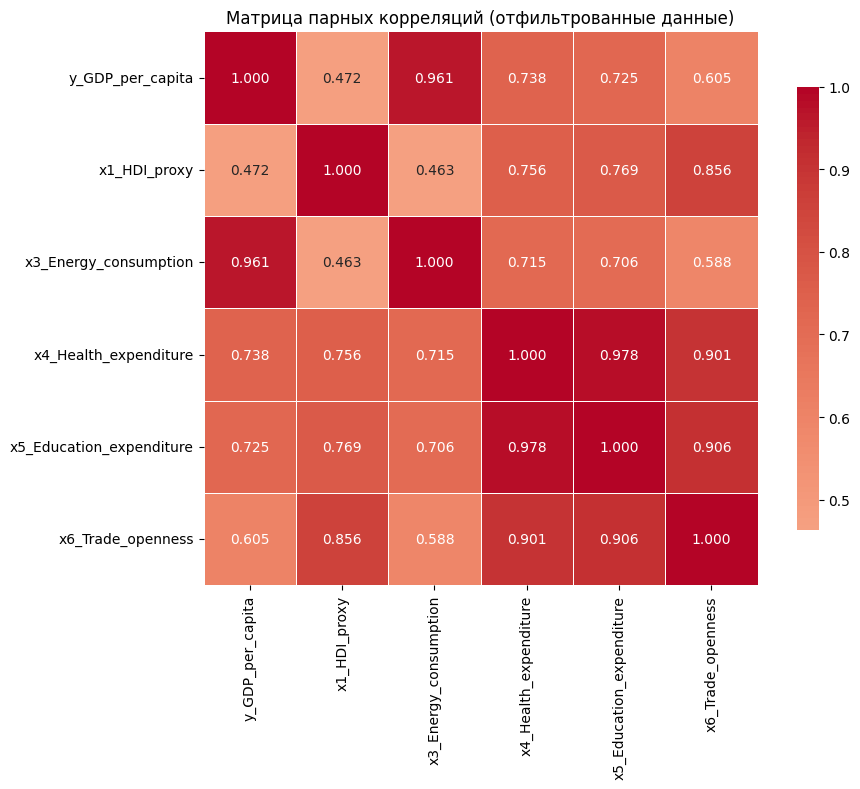


=== ВЫВОДЫ ПО ОТФИЛЬТРОВАННОЙ КОРРЕЛЯЦИОННОЙ МАТРИЦЕ ===
Зависимость y и сохраненных экзогенных переменных:
  x1_HDI_proxy: средняя положительная корреляция (r = +0.4720)
  x3_Energy_consumption: сильная положительная корреляция (r = +0.9614)
  x4_Health_expenditure: сильная положительная корреляция (r = +0.7383)
  x5_Education_expenditure: сильная положительная корреляция (r = +0.7246)
  x6_Trade_openness: средняя положительная корреляция (r = +0.6051)

Мультиколлинеарность между оставшимися факторами:
  x1_HDI_proxy <-> x4_Health_expenditure: r = +0.7560
  x1_HDI_proxy <-> x5_Education_expenditure: r = +0.7694
  x1_HDI_proxy <-> x6_Trade_openness: r = +0.8565
  x3_Energy_consumption <-> x4_Health_expenditure: r = +0.7149
  x3_Energy_consumption <-> x5_Education_expenditure: r = +0.7063
  x3_Energy_consumption <-> x6_Trade_openness: r = +0.5879
  x4_Health_expenditure <-> x5_Education_expenditure: r = +0.9783
  x4_Health_expenditure <-> x6_Trade_openness: r = +0.9006
  x5_Education_e

In [6]:
# Compute correlation matrix for filtered data
corr_matrix_filtered = data_filtered[selected_cols].corr(method='pearson')

print('Матрица парных коэффициентов корреляции Пирсона (отфильтрованные данные):')
print(corr_matrix_filtered.round(4))

# Extract correlations with y for filtered data
y_corr_filtered = corr_matrix_filtered['y_GDP_per_capita'].drop('y_GDP_per_capita')
print('\nКоэффициенты корреляции с y (отфильтрованные данные):')
for var, corr in y_corr_filtered.items():
    print(f'  {var}: r = {corr:+.4f}')

# Visualize filtered correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_filtered, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица парных корреляций (отфильтрованные данные)')
plt.tight_layout()
plt.show()

print('\n=== ВЫВОДЫ ПО ОТФИЛЬТРОВАННОЙ КОРРЕЛЯЦИОННОЙ МАТРИЦЕ ===')
print('Зависимость y и сохраненных экзогенных переменных:')
for var, corr in y_corr_filtered.items():
    strength = 'сильная' if abs(corr) >= 0.7 else 'средняя' if abs(corr) >= 0.4 else 'слабая'
    direction = 'положительная' if corr > 0 else 'отрицательная'
    print(f'  {var}: {strength} {direction} корреляция (r = {corr:+.4f})')

print('\nМультиколлинеарность между оставшимися факторами:')
x_only_cols = [col for col in selected_cols if col != 'y_GDP_per_capita']
has_collinearity = False
for i in range(len(x_only_cols)):
    for j in range(i+1, len(x_only_cols)):
        var1 = x_only_cols[i]
        var2 = x_only_cols[j]
        corr_val = corr_matrix_filtered.loc[var1, var2]
        if abs(corr_val) > 0.5:
            print(f'  {var1} <-> {var2}: r = {corr_val:+.4f}')
            has_collinearity = True

if not has_collinearity:
    print('  Выраженной мультиколлинеарности между факторами не обнаружено.')

print(f'\nИТОГОВЫЙ ВЫВОД:')
print(f'  Исходная модель содержала 6 факторов.')
print(f'  Исключено факторов (|r| < 0.4): {len(excluded_factors)}')
print(f'  Сохранено факторов: {len(significant_factors)}')
print(f'  Улучшение: удаление слабых факторов повышает качество модели и снижает шум.')